# Lista 02 - Estatística

**Questão 01 - Usando o mesmo portfolio da sua lista anterior, normalize os retornos logarítmicos,( z-score). O que ele significa?**

In [15]:
#não estava conseguindo baixar essa biblioteca pelo terminal
%pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:

# Usando o mesmo portfólio da lista anterior, normalizaremos os log-retornos via z-score.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def localizar_arquivo(nome_arquivo):
    """Procura o arquivo no diretório atual e em /mnt/data."""
    candidatos = [Path('.'), Path('/mnt/data')]
    for pasta in candidatos:
        caminho = pasta / nome_arquivo
        if caminho.exists():
            return caminho
    raise FileNotFoundError(f'Arquivo não encontrado: {nome_arquivo}')


def carregar_dados_portfolio():
    # Preços das ações
    precos = pd.read_csv(localizar_arquivo('precos_ajustados.csv'))
    precos['Data'] = pd.to_datetime(precos['Data'])
    precos = precos.set_index('Data').sort_index()

    # Mantendo somente a amostra comum entre os 5 ativos
    precos = precos.dropna().copy()

    # Retornos simples dos ativos
    retornos_acoes = precos.pct_change().dropna()

    # Mesmo portfólio da lista anterior: pesos iguais entre os 5 ativos
    pesos = np.repeat(1 / retornos_acoes.shape[1], retornos_acoes.shape[1])
    retorno_portfolio = retornos_acoes.dot(pesos)
    log_retorno_portfolio = np.log1p(retorno_portfolio)

    # Ibovespa para a questão 8
    ibov = pd.read_csv(localizar_arquivo('ibov.csv.csv'))
    ibov['Data'] = pd.to_datetime(ibov['Data'], errors='coerce')
    coluna_ibov = 'Fechamento|ajust p/ prov|Em moeda orig'
    ibov[coluna_ibov] = pd.to_numeric(ibov[coluna_ibov], errors='coerce')
    ibov = ibov[['Data', coluna_ibov]].dropna().set_index('Data').sort_index()
    retorno_ibov = ibov[coluna_ibov].pct_change().dropna()
    log_retorno_ibov = np.log1p(retorno_ibov)

    return {
        'precos': precos,
        'retornos_acoes': retornos_acoes,
        'pesos': pesos,
        'retorno_portfolio': retorno_portfolio,
        'log_retorno_portfolio': log_retorno_portfolio,
        'retorno_ibov': retorno_ibov,
        'log_retorno_ibov': log_retorno_ibov,
    }


# Carregando tudo uma vez para ser reutilizado nas questões seguintes
dados = carregar_dados_portfolio()
log_ret = dados['log_retorno_portfolio']

# Z-score: (x - média) / desvio padrão
z_score = (log_ret - log_ret.mean()) / log_ret.std(ddof=1)

display(z_score.to_frame(name='z_score').head())
print(f'Média dos log-retornos: {log_ret.mean():.6f}')
print(f'Desvio padrão dos log-retornos: {log_ret.std(ddof=1):.6f}')
print(f'Média do z-score: {z_score.mean():.6f}')
print(f'Desvio padrão do z-score: {z_score.std(ddof=1):.6f}')

,z_score
Data,
2021-03-01,25.003525
2021-03-02,0.562033
2021-03-03,0.147984
2021-03-04,0.538522
2021-03-05,1.056157


Média dos log-retornos: 0.000553
Desvio padrão dos log-retornos: 0.023021
Média do z-score: 0.000000
Desvio padrão do z-score: 1.000000


O z-score mostra quantos desvios padrão cada log-retorno está acima ou abaixo da média da série.
Se :
z > 0: retorno acima da média;
z < 0: retorno abaixo da média;
z = 0: retorno exatamente igual à média.

Essa padronização é útil porque coloca a série numa escala comum, com média próxima de 0 e desvio padrão igual a 1, facilitando comparações e análises de distribuição.

**Questão 02 - Com os retornos normalizados, plote um histograma deles. Também adicione uma curva de gauss e 3 curvas de t-student com n = 5,10 e 50. O que difere a t-student da curva gaussiana?**

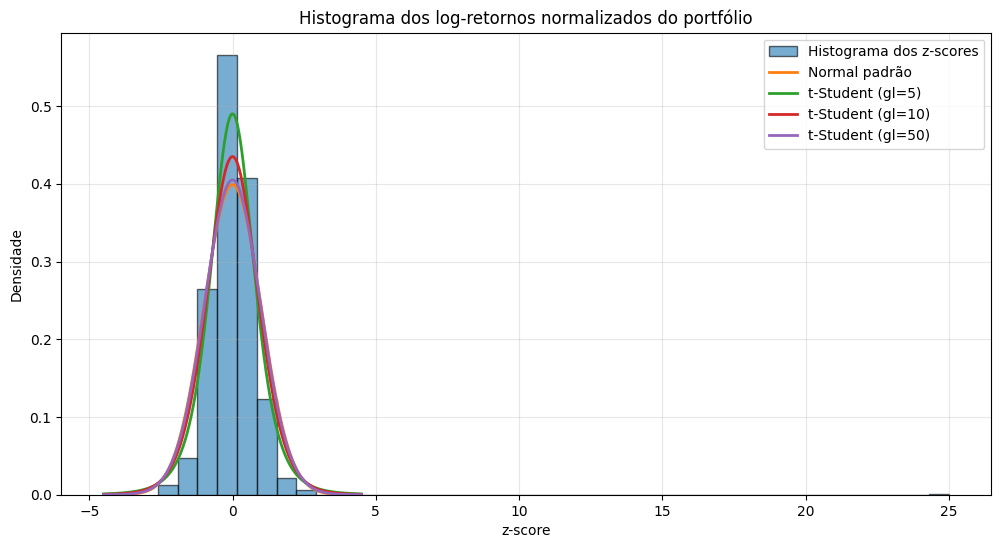

In [17]:
# Histograma dos retornos normalizados + curva normal + curvas t-Student com gl = 5, 10 e 50.

x = np.linspace(-4.5, 4.5, 1000)

plt.figure(figsize=(12, 6))
plt.hist(z_score, bins=40, density=True, alpha=0.6, edgecolor='black', label='Histograma dos z-scores')

# Curva normal padrão
plt.plot(x, stats.norm.pdf(x, loc=0, scale=1), linewidth=2, label='Normal padrão')

# Curvas t-Student padronizadas para variância unitária
for gl in [5, 10, 50]:
    escala = np.sqrt((gl - 2) / gl)
    densidade_t = stats.t.pdf(x / escala, df=gl) / escala
    plt.plot(x, densidade_t, linewidth=2, label=f't-Student (gl={gl})')

plt.title('Histograma dos log-retornos normalizados do portfólio')
plt.xlabel('z-score')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A principal diferença entre a t-Student e a normal (gaussiana) está nas caudas. A t-Student tem caudas mais pesadas, ou seja, atribui maior probabilidade a valores extremos.

**Questão 03 - Considerando que os log retornos são normais, calcule a probabilidade de termos um retorno acima de 3%**

In [18]:
# Probabilidade de o log-retorno do portfólio ser superior a 3%, assumindo normalidade.

mu = log_ret.mean()
sigma = log_ret.std(ddof=1)

limite = 0.03  # 3%
prob_acima_3 = 1 - stats.norm.cdf(limite, loc=mu, scale=sigma)

print(f'Média estimada dos log-retornos: {mu:.6f}')
print(f'Desvio padrão estimado dos log-retornos: {sigma:.6f}')
print(f'P(R > 3%) assumindo normalidade = {prob_acima_3:.6f}')
print(f'Em porcentagem: {prob_acima_3 * 100:.2f}%')

Média estimada dos log-retornos: 0.000553
Desvio padrão estimado dos log-retornos: 0.023021
P(R > 3%) assumindo normalidade = 0.100426
Em porcentagem: 10.04%


**Questão 04 - Plote a PDF e a CDF dos log-retornos do seu portfólio.**

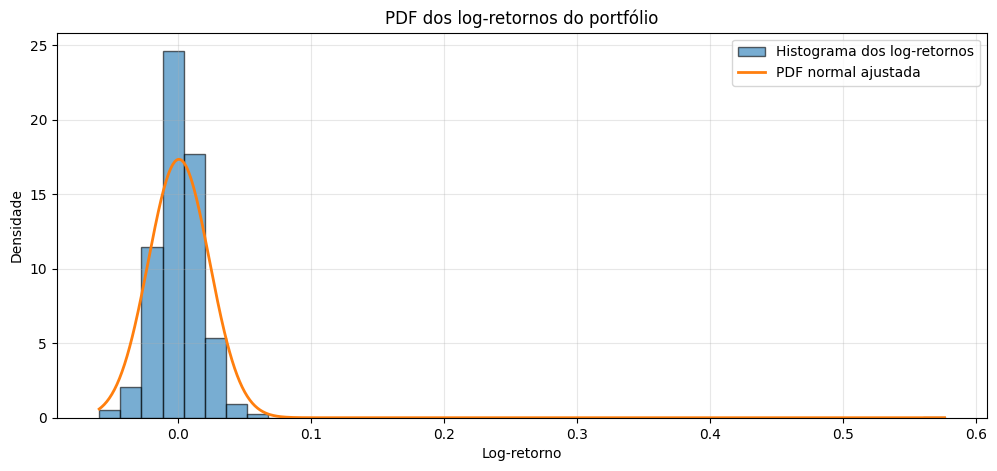

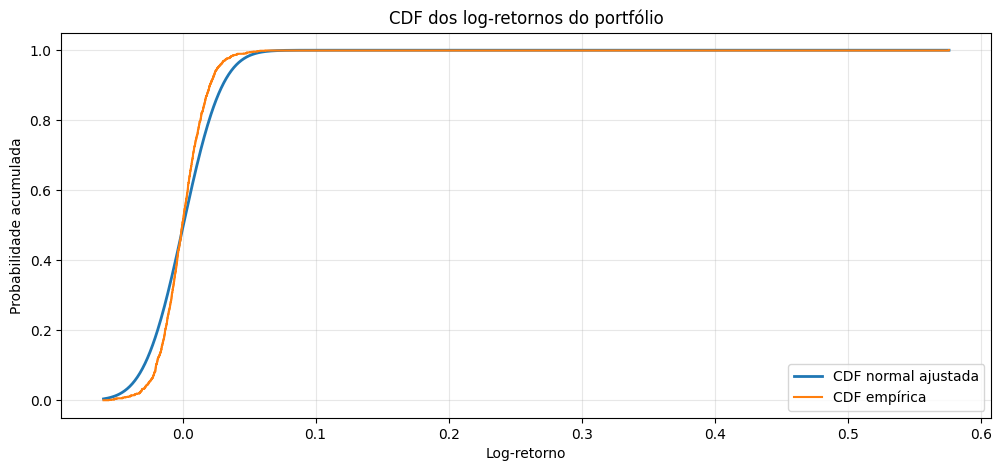

In [19]:
# PDF e CDF dos log-retornos do portfólio.

x_pdf = np.linspace(log_ret.min(), log_ret.max(), 1000)
pdf_ajustada = stats.norm.pdf(x_pdf, loc=mu, scale=sigma)
cdf_ajustada = stats.norm.cdf(x_pdf, loc=mu, scale=sigma)

# PDF
plt.figure(figsize=(12, 5))
plt.hist(log_ret, bins=40, density=True, alpha=0.6, edgecolor='black', label='Histograma dos log-retornos')
plt.plot(x_pdf, pdf_ajustada, linewidth=2, label='PDF normal ajustada')
plt.title('PDF dos log-retornos do portfólio')
plt.xlabel('Log-retorno')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# CDF teórica + CDF empírica
ret_ordenado = np.sort(log_ret)
cdf_empirica = np.arange(1, len(ret_ordenado) + 1) / len(ret_ordenado)

plt.figure(figsize=(12, 5))
plt.plot(x_pdf, cdf_ajustada, linewidth=2, label='CDF normal ajustada')
plt.step(ret_ordenado, cdf_empirica, where='post', linewidth=1.5, label='CDF empírica')
plt.title('CDF dos log-retornos do portfólio')
plt.xlabel('Log-retorno')
plt.ylabel('Probabilidade acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Questão 05 - Encontre kurtosis e skewness do retornos logarítmicos do seu portfólio. Qual o significado dessas medidas? Quais são os valores para uma normal padrão e qual o significado da diferença desses valores para o seu portfólio e para uma normal padrão?**


In [20]:
# Skewness e kurtosis dos log-retornos do portfólio.

skewness = stats.skew(log_ret, bias=False)
excesso_kurtosis = stats.kurtosis(log_ret, fisher=True, bias=False)
kurtosis_pearson = stats.kurtosis(log_ret, fisher=False, bias=False)

print(f'Skewness (assimetria): {skewness:.6f}')
print(f'Kurtosis em excesso: {excesso_kurtosis:.6f}')
print(f'Kurtosis de Pearson: {kurtosis_pearson:.6f}')
print()
print('Referência para a normal padrão:')
print('Skewness = 0')
print('Kurtosis em excesso = 0')
print('Kurtosis de Pearson = 3')

Skewness (assimetria): 12.315255
Kurtosis em excesso: 306.936166
Kurtosis de Pearson: 309.936166

Referência para a normal padrão:
Skewness = 0
Kurtosis em excesso = 0
Kurtosis de Pearson = 3


Skewness (assimetria) mede se a distribuição é inclinada para a direita ou para a esquerda.
- se0: distribuição simétrica.
- se> 0: cauda mais longa à direita.
- se< 0: cauda mais longa à esquerda.

Kurtosis mede o peso das caudas e o grau de concentração em torno do centro.
-Na convenção de excesso de kurtosis, a normal padrão tem valor 0.
-Na convenção de Pearson, a normal padrão tem valor 3.

Se o seu portfólio apresentar valores muito diferentes dos da normal, isso sugere que a distribuição dos retornos tem comportamento diferente da gaussiana, especialmente no que diz respeito a extremos e assimetria.

**Questão 06 - Considerando que os retornos são normais, calcule o percentil 25% dos retornos e a porcentagem dos dias que teremos retornos negativos**

In [21]:
# Percentil de 25% e probabilidade de retorno negativo, assumindo normalidade.

percentil_25 = stats.norm.ppf(0.25, loc=mu, scale=sigma)
prob_retorno_negativo = stats.norm.cdf(0, loc=mu, scale=sigma)

# Também calculando a fração empírica de dias negativos, para comparação
frac_empirica_negativos = (log_ret < 0).mean()

print(f'Percentil de 25% (teórico, normal): {percentil_25:.6f}')
print(f'Probabilidade teórica de retorno negativo: {prob_retorno_negativo:.6f}')
print(f'Probabilidade teórica de retorno negativo: {prob_retorno_negativo * 100:.2f}%')
print(f'Fração empírica de dias com retorno negativo: {frac_empirica_negativos * 100:.2f}%')

Percentil de 25% (teórico, normal): -0.014974
Probabilidade teórica de retorno negativo: 0.490413
Probabilidade teórica de retorno negativo: 49.04%
Fração empírica de dias com retorno negativo: 50.86%


**Questão 07 - O que é o máximo drawdown? Calcule o máximo drawdown do seu portfólio. Interprete o resultado.**


Máximo drawdown: -0.474331
Máximo drawdown em %: -47.43%
Data do pico anterior: 2021-06-14
Data do fundo do drawdown: 2022-07-04


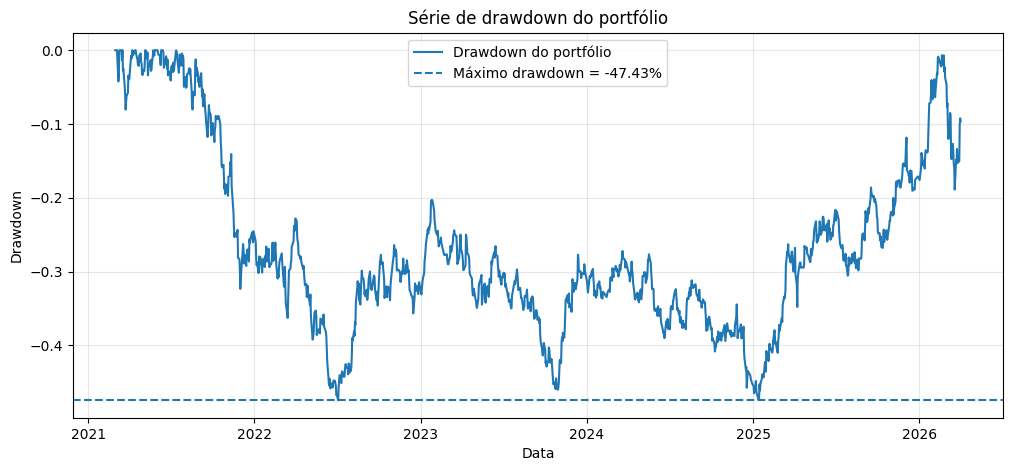

In [22]:
# Máximo drawdown do portfólio.

ret_port = dados['retorno_portfolio']
retorno_acumulado = (1 + ret_port).cumprod()
maximo_acumulado = retorno_acumulado.cummax()
drawdown = retorno_acumulado / maximo_acumulado - 1

max_drawdown = drawdown.min()
data_fundo = drawdown.idxmin()
data_pico = retorno_acumulado.loc[:data_fundo].idxmax()

print(f'Máximo drawdown: {max_drawdown:.6f}')
print(f'Máximo drawdown em %: {max_drawdown * 100:.2f}%')
print(f'Data do pico anterior: {data_pico.date()}')
print(f'Data do fundo do drawdown: {data_fundo.date()}')

plt.figure(figsize=(12, 5))
plt.plot(drawdown.index, drawdown, label='Drawdown do portfólio')
plt.axhline(max_drawdown, linestyle='--', label=f'Máximo drawdown = {max_drawdown:.2%}')
plt.title('Série de drawdown do portfólio')
plt.xlabel('Data')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

O máximo drawdown mede a maior queda percentual do portfólio a partir de um pico anterior até o fundo seguinte. Quanto mais negativo for o máximo drawdown, maior foi a queda sofrida pela carteira antes de se recuperar.

**Questão 08 - Teste se os retornos do portfólio são estatisticamente diferentes de zero e do retorno do índice BOVESPA. Qual alpha você utilizaria?**

In [23]:
# Testar se os retornos do portfólio são diferentes de zero e do retorno do Ibovespa.

alpha = 0.05

log_ret_port = dados['log_retorno_portfolio']
log_ret_ibov = dados['log_retorno_ibov']

# Alinhando as datas para comparar portfólio e Ibovespa corretamente
base_teste = pd.concat([
    log_ret_port.rename('portfolio'),
    log_ret_ibov.rename('ibov')
], axis=1).dropna()

# Teste 1: média dos log-retornos do portfólio é diferente de zero?
teste_zero = stats.ttest_1samp(base_teste['portfolio'], popmean=0)

# Teste 2: média dos log-retornos do portfólio é diferente da média dos log-retornos do Ibovespa?
# Como as séries estão alinhadas no tempo, usamos teste t pareado.
teste_ibov = stats.ttest_rel(base_teste['portfolio'], base_teste['ibov'])

print(f'Alfa adotado: {alpha:.2%}')
print()
print('Teste contra zero:')
print(f'Estatística t = {teste_zero.statistic:.6f}')
print(f'p-valor = {teste_zero.pvalue:.6f}')
print('Conclusão:', 'rejeita H0' if teste_zero.pvalue < alpha else 'não rejeita H0')

print()
print('Teste contra o Ibovespa:')
print(f'Estatística t = {teste_ibov.statistic:.6f}')
print(f'p-valor = {teste_ibov.pvalue:.6f}')
print('Conclusão:', 'rejeita H0' if teste_ibov.pvalue < alpha else 'não rejeita H0')

print()
print('Médias amostrais:')
print(f'Média do log-retorno do portfólio: {base_teste["portfolio"].mean():.6f}')
print(f'Média do log-retorno do Ibovespa: {base_teste["ibov"].mean():.6f}')

Alfa adotado: 5.00%

Teste contra zero:
Estatística t = 0.857148
p-valor = 0.391525
Conclusão: não rejeita H0

Teste contra o Ibovespa:
Estatística t = 0.244099
p-valor = 0.807193
Conclusão: não rejeita H0

Médias amostrais:
Média do log-retorno do portfólio: 0.000553
Média do log-retorno do Ibovespa: 0.000421


C:\Users\ferna\AppData\Local\Temp\ipykernel_24460\4077591186.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  base_teste = pd.concat([


Usei α = 5%, porque é o nível de significância mais comum em aplicações estatísticas, onde o nível de confiança é de 95%. Alpha é calculado por (1-Nível de confiança
)